C:\Users\alwaz\AppData\Local\Temp\ipykernel_32460\241174522.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


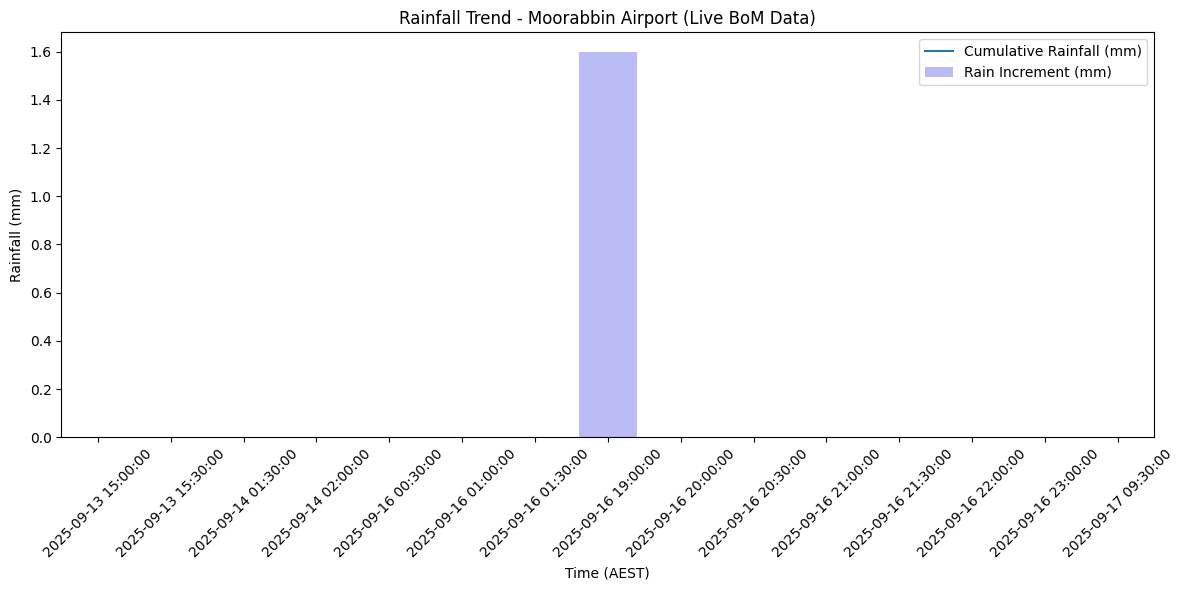

In [4]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect DB
conn = psycopg2.connect(
    dbname="flood_project",
    user="postgres",
    password="admin123",
    host="localhost",
    port="5432"
)

query = """
SELECT obs_time, rainfall_since_9am, rain_increment
FROM rainfall_live
ORDER BY obs_time ASC;
"""
df = pd.read_sql(query, conn)
conn.close()

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(x="obs_time", y="rainfall_since_9am", data=df, label="Cumulative Rainfall (mm)")
sns.barplot(x="obs_time", y="rain_increment", data=df, color="blue", alpha=0.3, label="Rain Increment (mm)")
plt.xticks(rotation=45)
plt.xlabel("Time (AEST)")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall Trend - Moorabbin Airport (Live BoM Data)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect DB
conn = psycopg2.connect(
    dbname="flood_project",
    user="postgres",
    password="admin123",
    host="localhost",
    port="5432"
)

# --- Query 1: Historical Daily Rainfall ---
q_hist = """
SELECT obs_time, rainfall_since_9am_mm
FROM rainfall_obs
ORDER BY obs_time ASC;
"""
df_hist = pd.read_sql(q_hist, conn)

# --- Query 2: IFD Design Rainfall ---
q_ifd = """
SELECT duration_minutes, ari_years, depth_mm
FROM ifd_lookup
ORDER BY duration_minutes, ari_years;
"""
df_ifd = pd.read_sql(q_ifd, conn)

conn.close()

# --- Plot 1: Historical Daily Rainfall ---
plt.figure(figsize=(14, 5))
plt.bar(df_hist["obs_time"], df_hist["rainfall_since_9am_mm"], color="teal", alpha=0.7)
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Daily Rainfall (mm)")
plt.title("Historical Daily Rainfall - Frankston Station")
plt.tight_layout()
plt.show()

# --- Plot 2: IFD Curves ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_ifd, x="duration_minutes", y="depth_mm", hue="ari_years", marker="o")
plt.xscale("log")
plt.xlabel("Duration (minutes, log scale)")
plt.ylabel("Rainfall Depth (mm)")
plt.title("IFD Curves - Frankston")
plt.legend(title="ARI (years)")
plt.tight_layout()
plt.show()


C:\Users\alwaz\AppData\Local\Temp\ipykernel_32460\2175643765.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_hist = pd.read_sql(q_hist, conn)


DatabaseError: Execution failed on sql '
SELECT obs_time, rainfall_mm
FROM rainfall_obs
ORDER BY obs_time ASC;
': column "rainfall_mm" does not exist
LINE 2: SELECT obs_time, rainfall_mm
                         ^
